## Import Liberaries

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## Read the Dataset

In [3]:
df = pd.read_csv('customer_segmentation.csv')

## EDA(Exploratry Data Analysis)

In [4]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  str    
 2   Ever_Married     10505 non-null  str    
 3   Age              10695 non-null  int64  
 4   Graduated        10593 non-null  str    
 5   Profession       10533 non-null  str    
 6   Work_Experience  9597 non-null   float64
 7   Spending_Score   10695 non-null  str    
 8   Family_Size      10247 non-null  float64
 9   Var_1            10587 non-null  str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 919.2 KB


Checking for null Values

In [6]:
df.isna().sum()

ID                    0
Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1               108
Segmentation       2627
dtype: int64

In [7]:
df=df.drop(columns=['ID','Gender','Ever_Married','Graduated','Profession','Spending_Score','Var_1','Segmentation'])

In [9]:
df.head()

,Age,Work_Experience,Family_Size
0,22,1.0,4.0
1,38,NaN,3.0
2,67,1.0,1.0
3,67,0.0,2.0
4,40,NaN,6.0


Dropping the null values

In [10]:
df = df.dropna()

In [19]:
df.isna().sum()

Age                0
Work_Experience    0
Family_Size        0
clusters           0
dtype: int64

Using Standard Scaler

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

K-Means 

In [12]:
inertia_values = []
silhouette_scores = []
K_range = range(2,11)

for K in K_range:
    kmeans=KMeans(n_clusters=K,random_state=42)
    kmeans.fit(df_scaled)

    # Inertia
    inertia_values.append(kmeans.inertia_)

    # Silhouette Score 
    silhouette = silhouette_score(df_scaled,kmeans.labels_)
    silhouette_scores.append(silhouette)

## Elbow Method

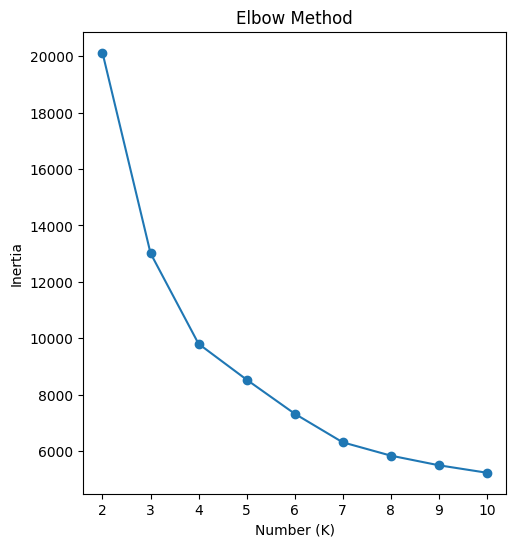

In [13]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(K_range,inertia_values,marker='o',linestyle='-')
plt.xlabel("Number (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Silhouette Scores

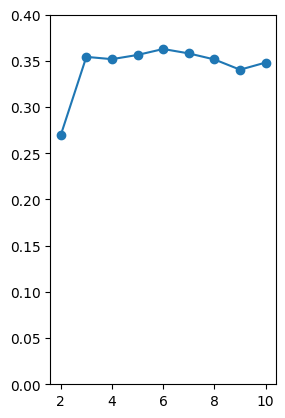

In [14]:
plt.subplot(1,2,2)
plt.plot(K_range,silhouette_scores,marker='o',linestyle='-')
plt.ylim((0,0.4))
plt.show()

## KMeans

In [15]:
kmeans= KMeans(n_clusters=3,max_iter=500,verbose=1)
kmeans.fit(df_scaled)

Initialization complete
Iteration 0, inertia 20128.761701566447.
Iteration 1, inertia 14016.883619562426.
Iteration 2, inertia 13266.878819274543.
Iteration 3, inertia 13124.660611739384.
Iteration 4, inertia 13073.360366794906.
Iteration 5, inertia 13046.935848330762.
Iteration 6, inertia 13028.106823887549.
Iteration 7, inertia 13019.441864570457.
Iteration 8, inertia 13015.555399267007.
Iteration 9, inertia 13014.515352979008.
Converged at iteration 9: center shift 9.304202398841967e-06 within tolerance 0.00010000000000000175.


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",500
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
labels = kmeans.predict(df_scaled)

In [17]:
df['clusters'] = labels

In [18]:
df.head()

,Age,Work_Experience,Family_Size,clusters
0,22,1.0,4.0,2
2,67,1.0,1.0,1
3,67,0.0,2.0,1
5,56,0.0,2.0,1
6,32,1.0,3.0,2


In [20]:
df.clusters.value_counts()

clusters
1    3814
2    3344
0    2078
Name: count, dtype: int64

In [21]:
df.groupby('clusters')['Age'].mean()

clusters
0    37.451396
1    55.702412
2    33.252093
Name: Age, dtype: float64

In [23]:
df.groupby('clusters')['Work_Experience'].median()

clusters
0    8.0
1    1.0
2    1.0
Name: Work_Experience, dtype: float64

In [25]:
df.groupby('clusters')['Work_Experience'].mean()

clusters
0    8.203080
1    0.899580
2    1.091208
Name: Work_Experience, dtype: float64